In [1]:
import os

In [2]:
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Base directory
base_path = '../data/image50_clahe/'

# Collect all image paths recursively in 0/ and 1/
all_images = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            all_images.append(os.path.join(root, file))

print(f"Total images found: {len(all_images)}")

# Randomly sample 1000
sample_size = 10000
sampled_images = random.sample(all_images, min(sample_size, len(all_images)))

# Initialize histograms
r_hist = np.zeros(256)
g_hist = np.zeros(256)
b_hist = np.zeros(256)

# Populate histograms
for img_path in tqdm(sampled_images):
    img = Image.open(img_path).convert("RGB")
    r, g, b = np.array(img).transpose(2, 0, 1)

    r_hist += np.histogram(r, bins=256, range=(0, 255))[0]
    g_hist += np.histogram(g, bins=256, range=(0, 255))[0]
    b_hist += np.histogram(b, bins=256, range=(0, 255))[0]

Total images found: 277524


100%|██████████| 10000/10000 [02:42<00:00, 61.36it/s]


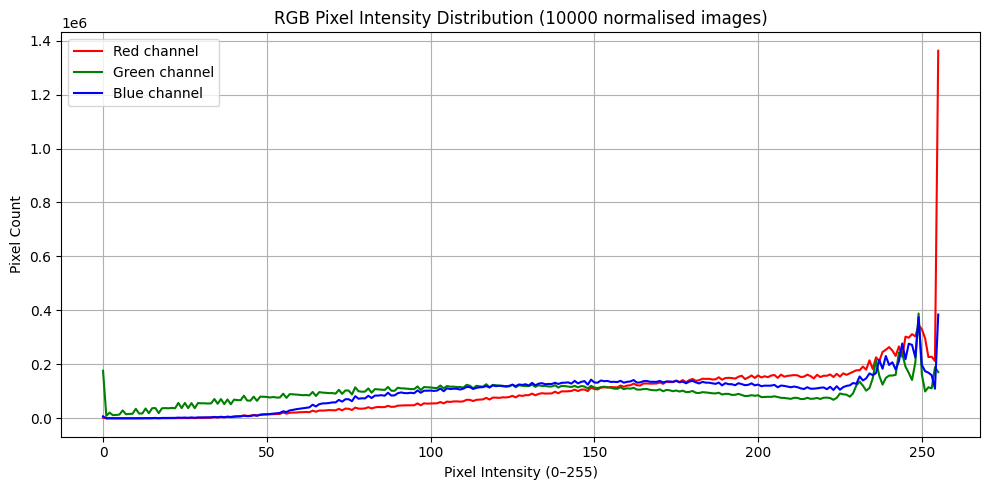

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(r_hist, color='red', label='Red channel')
plt.plot(g_hist, color='green', label='Green channel')
plt.plot(b_hist, color='blue', label='Blue channel')
plt.title(f"RGB Pixel Intensity Distribution ({sample_size} normalised images)")
plt.xlabel("Pixel Intensity (0–255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
all_images = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            all_images.append(os.path.join(root, file))

print(f"Total images found: {len(all_images)}")

sample_size = 10000
sampled_images = random.sample(all_images, min(sample_size, len(all_images)))

# Store contrast values (std of grayscale)
contrast_values = []

for img_path in tqdm(sampled_images):
    img = Image.open(img_path).convert("L")  # convert to grayscale
    pixels = np.array(img).astype(np.float32)
    std_dev = pixels.std()  # simple contrast metric
    contrast_values.append(std_dev)


Total images found: 277524


100%|██████████| 10000/10000 [02:25<00:00, 68.76it/s]


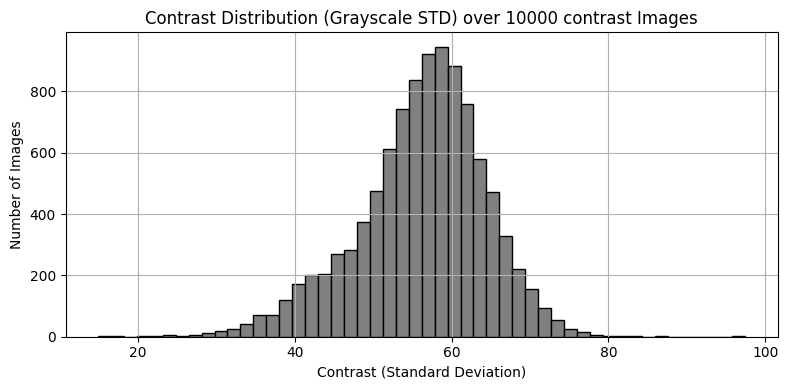

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(contrast_values, bins=50, color='gray', edgecolor='black')
plt.title(f"Contrast Distribution (Grayscale STD) over {sample_size} contrast Images")
plt.xlabel("Contrast (Standard Deviation)")
plt.ylabel("Number of Images")
plt.grid(True)
plt.tight_layout()
plt.show()
